# Imports + Seed

In [3]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
df = pd.read_csv("merged_df.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').set_index('time')



# Selecting features and target

In [5]:
features = [
    'generation solar',
    'generation wind onshore',
    'generation nuclear',
    'temp',
    'humidity',
    'wind_speed'
]
target = 'total load actual'

data = df[features + [target]].dropna()


# Scale Data

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns, index=data.index)


# creating 24 hour sequences:

In [7]:
def create_sequences(df, target_col, window=24):
    X, y = [], []
    for i in range(window, len(df)):
        X.append(df.iloc[i-window:i].values)
        y.append(df[target_col].iloc[i])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, target, window=24)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35040, 24, 7)
y shape: (35040,)


In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# Building GRU model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model_gru = Sequential([
    GRU(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0188 - val_loss: 0.0034
Epoch 2/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 3/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 4/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 9.5566e-04
Epoch 6/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0012 - val_loss: 8.3037e-04
Epoch 7/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0011 - val_loss: 7.4874e-04
Epoch 8/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 9.9574e-04 - val_loss: 6.8349e-04
Epoch 9/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 9.3320e-04 - val_loss: 6.6258e-04
Epoch 10/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 8.7736e-04 - val_loss: 6.5596e-04
Epoch 11/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 8.2451e-04 - val_loss: 6.5838e-04
Epoch 12

# 1. TRAIN + VALIDATION ERROR

In [10]:
train_loss = history_gru.history['loss'][-1]
val_loss   = history_gru.history['val_loss'][-1]

print("🔹 Train Loss (scaled MSE):", train_loss)
print("🔹 Val Loss   (scaled MSE):", val_loss)

🔹 Train Loss (scaled MSE): 0.000534864841029048
🔹 Val Loss   (scaled MSE): 0.0005554814706556499


# TEST ERROR (REAL MW)

In [11]:
# Predict
y_pred = model_gru.predict(X_test)

# Rebuild temp arrays for inverse transform
target_idx = scaled_df.columns.get_loc(target)

temp_test = np.zeros((len(y_test), scaled_df.shape[1]))
temp_test[:, target_idx] = y_test
y_test_inv = scaler.inverse_transform(temp_test)[:, target_idx]

temp_pred = np.zeros((len(y_pred), scaled_df.shape[1]))
temp_pred[:, target_idx] = y_pred.flatten()
y_pred_inv = scaler.inverse_transform(temp_pred)[:, target_idx]

# Metrics
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
r2   = r2_score(y_test_inv, y_pred_inv)

print("\n📊 GRU Test Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.3f}")


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 GRU Test Performance:
MAE  : 374.51
RMSE : 536.29
MAPE : 1.32%
R²   : 0.986


# Train vs Validation Plot

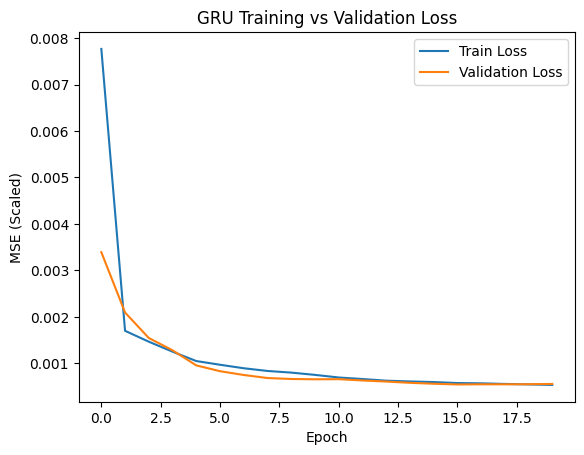

In [13]:
import matplotlib.pyplot as plt


plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE (Scaled)")
plt.title("GRU Training vs Validation Loss")
plt.legend()
plt.show()


# Plot Actual vs Predicted (First 200 Hours):

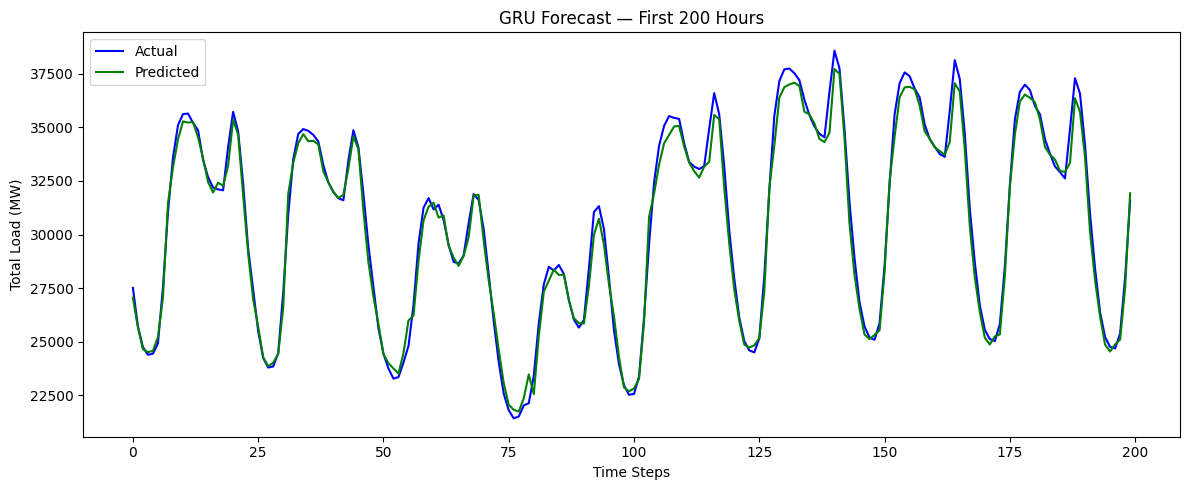

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv[:200], label='Actual', color='blue')
plt.plot(y_pred_inv[:200], label='Predicted', color='green')
plt.title("GRU Forecast — First 200 Hours")
plt.xlabel("Time Steps")
plt.ylabel("Total Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


# early stop

In [14]:
from tensorflow.keras.callbacks import EarlyStopping


In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,           # stop if no improvement for 3 epochs
    restore_best_weights=True
)


In [16]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,            # can keep high, early stop will prevent overfitting
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5.1240e-04 - val_loss: 4.9988e-04
Epoch 2/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.9844e-04 - val_loss: 4.8832e-04
Epoch 3/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.9214e-04 - val_loss: 4.8142e-04
Epoch 4/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.8178e-04 - val_loss: 4.6205e-04
Epoch 5/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.7205e-04 - val_loss: 4.4486e-04
Epoch 6/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.6264e-04 - val_loss: 4.3316e-04
Epoch 7/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.5462e-04 - val_loss: 4.2087e-04
Epoch 8/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.4371e-04 - val_loss: 4.1393e-04
Epoch 9/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.3768e-04 - val_loss: 4.0533e-04
Epoch 10/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.3152e-04 - val_loss: 4.0635e-04
Epoch 11/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss